In [1]:
import gc
import glob
import math
import os
import shutil
import subprocess
import sys
import time
import warnings
from collections import deque
from contextlib import nullcontext
from functools import partial
from typing import List, Optional, Tuple

import GPUtil
import colorama
import numpy as np
import torch
from torch.autograd.profiler import record_function
from torch.utils.data import DataLoader

import dist
from utils import arg_util, misc
from utils.data import build_dataset, pil_load
from utils.data_sampler import DistInfiniteBatchSampler
from models.vqvae import VQVAE
from utils.arg_util import Args
from PIL import Image
import matplotlib.pyplot as plt
import dist
import torch.distributed as tdist
from torchvision.transforms import InterpolationMode, transforms
from utils.data_loader import DIV2KData


args = Args()
# args.data = "./data/df2k_ost/GT_resized"
# args.data = "./data/DIV2K_train_HR"
# args.data = "./data/train"
# args.data = "./data/brats_256_t1_new/train"
args.data = "../data/brats_256_t1_2021_pair_4x/val"

/home/why/anaconda3/envs/VAR/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'
    tdist.init_process_group("nccl", rank=rank, world_size=world_size)
setup(0,1)

<All keys matched successfully>

In [3]:
def normalize_01_into_pm1(x):  # normalize x from [0, 1] to [-1, 1] by (x*2) - 1
    return x.add(x).add_(-1)

val_aug = [
        transforms.ToTensor(), normalize_01_into_pm1,
    ]
val_aug = transforms.Compose(val_aug)
val_set = DIV2KData(data_dir=args.data, transform=val_aug, augment=False)  # todo: junfeng; only `train_set` required, no need to create a 'validation_set'
ld_val = DataLoader(
    dataset=val_set, num_workers=args.workers, pin_memory=True,shuffle=True
)


In [ ]:

# vae_ckpt = f"ckpt_vaex/brats256-new/ckpt-150.pth"
vae_ckpt = f"local_output/ckpt-3.pth"
# vae_ckpt = f"local_output/ckpt-900.pth"
# vae_ckpt = f'vae_ch160v4096z32.pth'

args.vocab_size = 4096
args.vocab_width = 32
# args.vocab_size = 4096

vae = VQVAE(vocab_size=args.vocab_size, z_channels=args.vocab_width, ch=args.ch, 
            test_mode=True, share_quant_resi=args.share_quant_resi, v_patch_nums=args.patch_nums).to(args.device).eval()
# print(torch.load(vae_ckpt, map_location='cpu')['trainer']['vae_wo_ddp'])
vae.load_state_dict(torch.load(vae_ckpt, map_location='cpu')['trainer']['vae_wo_ddp'])
# vae.load_state_dict(torch.load(vae_ckpt, map_location='cpu'))

# x1 = torch.load(vae_ckpt, map_location='cpu')['trainer']['vae_wo_ddp']
# x2 = torch.load(vae_ckpt_init, map_location='cpu')
# for keys in x1.keys():
#     print(keys,x1[keys].mean() - x2[keys].mean())


tensor(0.4824) tensor(-0.8118) tensor(-0.2784) tensor(0.4465) torch.Size([1, 3, 256, 256])


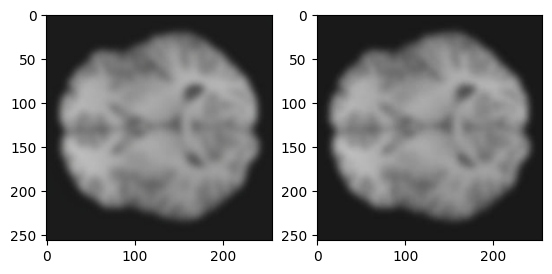

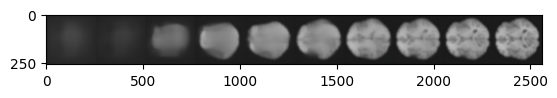

tensor(0.4588) tensor(-0.8980) tensor(-0.5648) tensor(0.3303) torch.Size([1, 3, 256, 256])


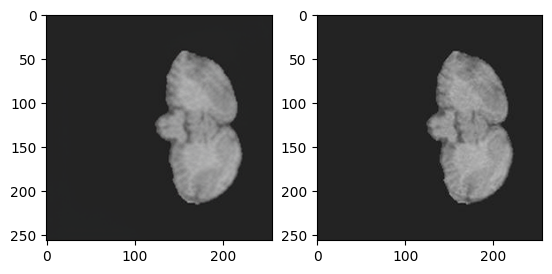

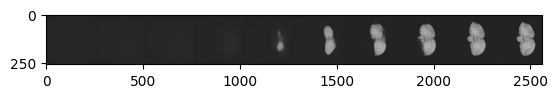

tensor(0.4667) tensor(-0.9216) tensor(-0.3741) tensor(0.3531) torch.Size([1, 3, 256, 256])


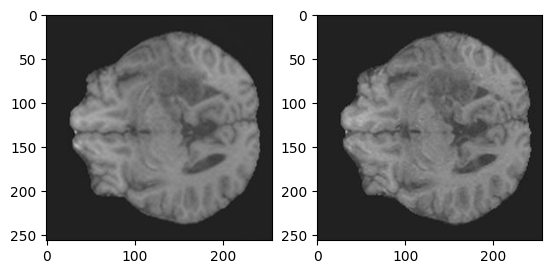

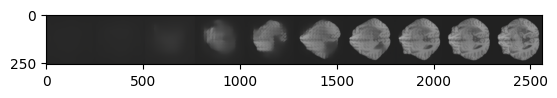

tensor(0.4588) tensor(-0.7569) tensor(-0.5625) tensor(0.3415) torch.Size([1, 3, 256, 256])


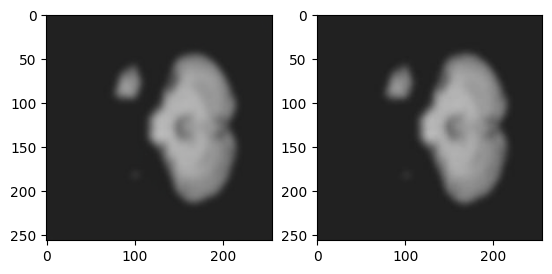

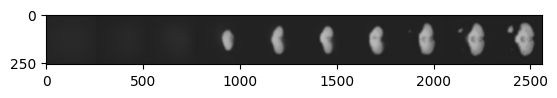

tensor(0.2549) tensor(-0.7255) tensor(-0.4328) tensor(0.3282) torch.Size([1, 3, 256, 256])


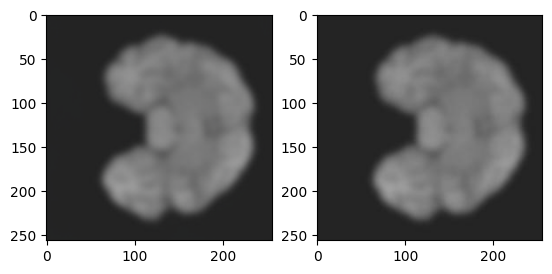

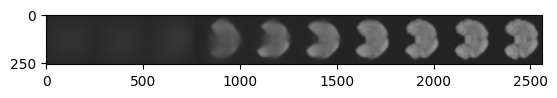

tensor(0.1922) tensor(-0.8039) tensor(-0.5592) tensor(0.3307) torch.Size([1, 3, 256, 256])


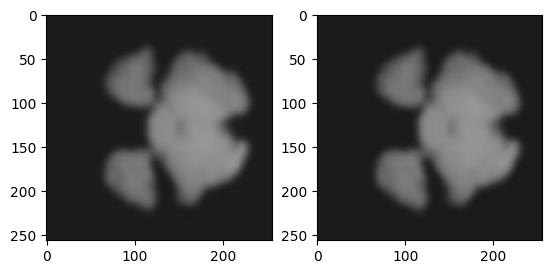

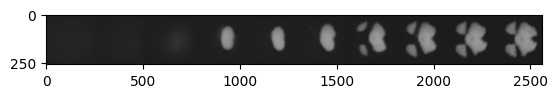

tensor(0.1843) tensor(-0.6941) tensor(-0.5102) tensor(0.2649) torch.Size([1, 3, 256, 256])


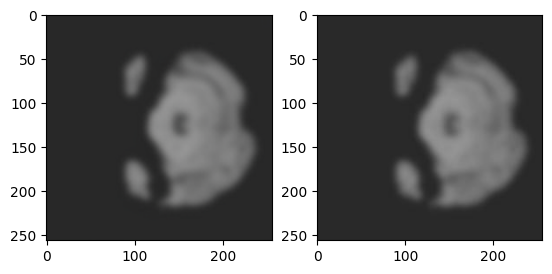

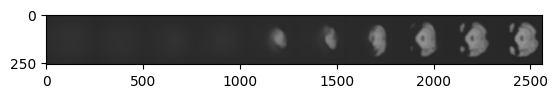

tensor(0.7255) tensor(-0.9373) tensor(-0.4097) tensor(0.4207) torch.Size([1, 3, 256, 256])


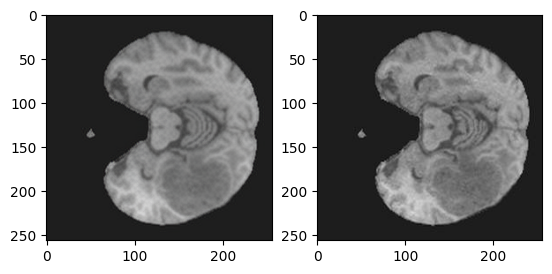

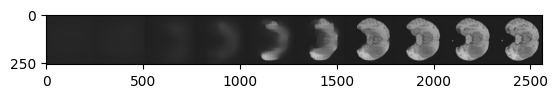

tensor(0.9059) tensor(-0.9608) tensor(-0.2743) tensor(0.4202) torch.Size([1, 3, 256, 256])


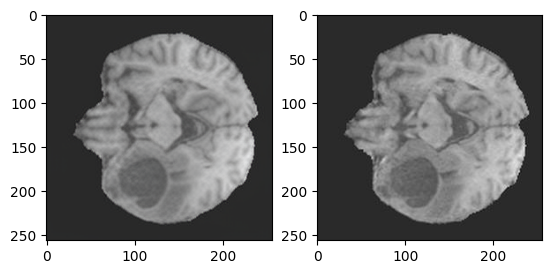

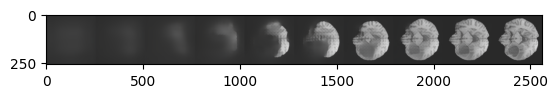

tensor(0.1686) tensor(-0.7569) tensor(-0.3959) tensor(0.3023) torch.Size([1, 3, 256, 256])


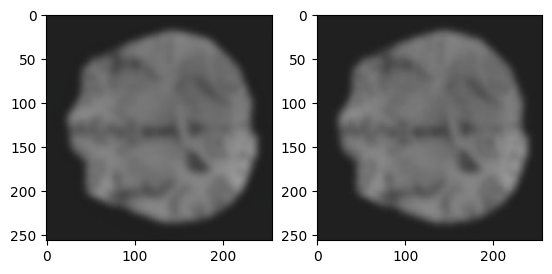

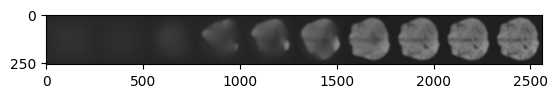

tensor(0.6157) tensor(-0.9608) tensor(-0.3313) tensor(0.4195) torch.Size([1, 3, 256, 256])


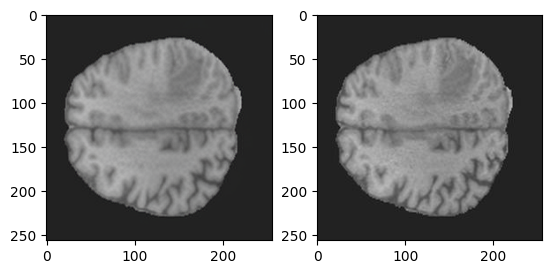

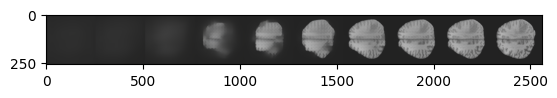

In [5]:
def process_image(x):
    """处理单张图片"""    
    x = x.clamp(-1.0, 1.0)
    x = x[0].detach().cpu().permute(1, 2, 0).numpy()  # 转换为 HWC 格式的 numpy 数组
    x = (x * 0.5 + 0.5) * 255  # 反归一化并缩放到 [0, 255]
    x = x.astype(np.uint8)  # 转换为 uint8
    return x

tot = 0
for data in ld_val:
    with torch.no_grad():
        data = data.to(args.device)
        print(data.max(), data.min(), data.mean(), data.std(),data.shape)
        
        rec_B3HW, usage , Lq  = vae(data)
        
        rec_B3HW = process_image(rec_B3HW)
        data_ = process_image(data)
        
        plt.figure()
        plt.subplot(1, 2, 1)
        plt.imshow(rec_B3HW)
        plt.subplot(1, 2, 2)
        plt.imshow(data_)
        plt.show()
        
        predict_idx = vae.img_to_idxBl(data)
        nup_predict = vae.idxBl_to_img(predict_idx, same_shape=True, last_one=False)
        predict_combined = np.concatenate([process_image(x) for x in nup_predict], axis=1)
        plt.imshow(predict_combined.astype(np.uint8))
        plt.show()
        
    tot = tot + 1
    if tot > 10:
        break
